In [1]:
import numpy as ny
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.shape

(891, 15)

In [4]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
df.drop(['class', 'who', 'adult_male', 'deck', 'embark_town','alive'],axis=1,inplace=True)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [9]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
alone         0
dtype: int64

In [11]:
df["age"].fillna(df["age"].mean(),inplace=True)
df["age"].isnull().sum()

np.int64(0)

In [12]:
df.dropna(subset="embarked",inplace=True)
df["embarked"].isnull().sum()

np.int64(0)

In [10]:
df.drop_duplicates(df,inplace=True)
df.shape

(780, 9)

In [13]:
X = df.drop("survived",axis=1)
y = df["survived"]
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,3,male,22.0,1,0,7.2500,S,False
1,1,female,38.0,1,0,71.2833,C,False
2,3,female,26.0,0,0,7.9250,S,True
3,1,female,35.0,1,0,53.1000,S,False
4,3,male,35.0,0,0,8.0500,S,True


In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
l = ["sex","embarked"]
for i in l:
    X[i] = le.fit_transform(X[i])
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,3,1,22.0,1,0,7.2500,2,False
1,1,0,38.0,1,0,71.2833,0,False
2,3,0,26.0,0,0,7.9250,2,True
3,1,0,35.0,1,0,53.1000,2,False
4,3,1,35.0,0,0,8.0500,2,True


In [15]:
X["alone"] = X["alone"].astype(int)
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,3,1,22.0,1,0,7.2500,2,0
1,1,0,38.0,1,0,71.2833,0,0
2,3,0,26.0,0,0,7.9250,2,1
3,1,0,35.0,1,0,53.1000,2,0
4,3,1,35.0,0,0,8.0500,2,1


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[["age","fare"]] = scaler.fit_transform(X[["age","fare"]])
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,3,1,-0.567905,1,0,-0.525640,2,0
1,1,0,0.602904,1,0,0.699954,0,0
2,3,0,-0.275203,0,0,-0.512721,2,1
3,1,0,0.383377,1,0,0.351927,2,0
4,3,1,0.383377,0,0,-0.510328,2,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix

In [20]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)
model1 = LogisticRegression()
model1.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
model2 = KNeighborsClassifier()
model2.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.75      0.82      0.79        91
           1       0.71      0.62      0.66        65

    accuracy                           0.74       156
   macro avg       0.73      0.72      0.72       156
weighted avg       0.74      0.74      0.73       156



0.7371794871794872

<Axes: >

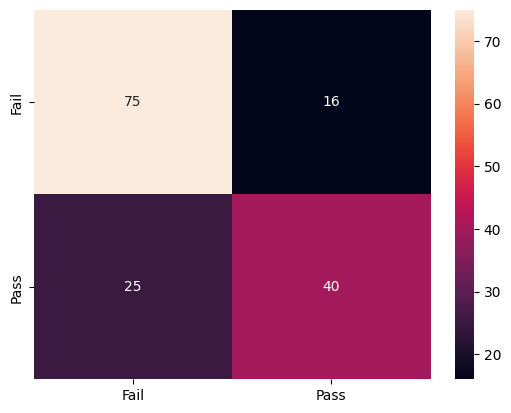

In [33]:
sns.heatmap(confusion_matrix(y_test,y_pred1),annot=True,xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])

In [ ]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.72      0.88      0.79        91
           1       0.76      0.52      0.62        65

    accuracy                           0.73       156
   macro avg       0.74      0.70      0.71       156
weighted avg       0.74      0.73      0.72       156



<Axes: >

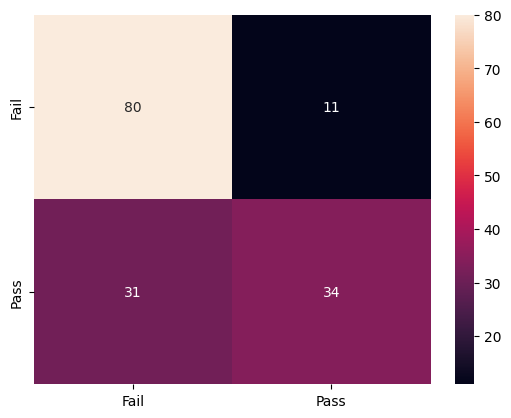

In [34]:
sns.heatmap(confusion_matrix(y_test,y_pred2),annot=True,xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])